In [1]:
import numpy as np
import pandas 
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [8]:
data.DESCR

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [9]:
x = data.data
y = data.target

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

0.4526027629719196

In [13]:
y_pred = model.predict(x_test)  


In [14]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("R2 Score : ",r2_score(y_test,y_pred))
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))

R2 Score :  0.4526027629719196
MAE :  42.79409467959994
MSE :  2900.1936284934804


# Pre build Ridge regression class

In [15]:
from turtle import mode

from sklearn.linear_model import Ridge
model2 = Ridge(alpha=0.001)
model2.fit(x_train,y_train)
y_pred2 = model2.predict(x_test)
print("R2 Score : ",r2_score(y_test,y_pred2))
print("MAE : ",mean_absolute_error(y_test,y_pred2))

R2 Score :  0.453428030101933
MAE :  42.803081786411205


In [20]:
model2.coef_
model2.intercept_

151.3419805679864

# self build reidge regression class

In [35]:
#reproducibility
np.random.seed(42)

# 1D feature data
n_samples = 100
x = np.linspace(0, 10, n_samples)             # shape: (100,)

# target with linear relation + noise
noise = np.random.normal(0, 2, n_samples)
y = 3.5 * x + 8 + noise           

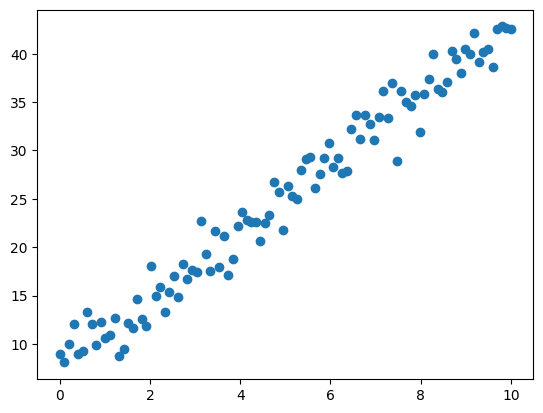

In [36]:
plt.scatter(x, y)

In [37]:
print(x.shape)  # (100,)
print(y.shape)  # (100,)

(100,)
(100,)


In [38]:
x = x.reshape(-1,1)
y = y.reshape(-1,1)   

model2.fit(x,y)
model2.coef_,model2.intercept_

(array([3.52758239]), array([7.65439504]))

In [39]:
class selfRidge:
    def __init__(self,alpha=0.001):
        self.alpha = alpha
        self.m = None
        self.b = None
    def fit(self,x_train,y_train):
        num = 0
        den = 0
        for i in range(x_train.shape[0]):
            num += np.sum((y_train[i] - np.mean(y_train)) * (x_train[i] - np.mean(x_train)))
            den += np.sum((x_train[i] - np.mean(x_train))**2)
        self.m = num/(den+self.alpha)
        self.b = np.mean(y_train) - self.m*np.mean(x_train)
    def predict(self,x_test):
        y_pred = []
        return self.m * x_test + self.b
        

In [40]:
model3 = selfRidge(alpha=0.001)
model3.fit(x,y)
print(model3.m,model3.b)

3.5275823853981922 7.654395038220855
